In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os

PROJECT_DIR = "/content/drive/MyDrive/Multispectral-Domain-Generalization"
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
DATA_DIR = os.path.join(PROJECT_DIR, "data")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Figures directory:", FIGURES_DIR)
print("Data directory:", DATA_DIR)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Multispectral-Domain-Generalization
Figures directory: /content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures
Data directory: /content/drive/MyDrive/Multispectral-Domain-Generalization/data


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TFDS version:", tfds.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
TFDS version: 4.9.9
GPU available: True


In [5]:
# Install TIFF reader
!pip -q install tifffile tqdm

import os
import glob
import zipfile
import shutil
import tifffile
from pathlib import Path
from tqdm.auto import tqdm

DATASET_NAME = "EuroSAT_MS"

EUROSAT_ZIP_URL = "https://zenodo.org/records/7711810/files/EuroSAT_MS.zip?download=1"

# Keep zip backup in Google Drive
DRIVE_ZIP_PATH = os.path.join(DATA_DIR, "EuroSAT_MS.zip")

# Use local Colab disk for extraction and reading
LOCAL_DATA_ROOT = "/content/eurosat_data"
LOCAL_ZIP_PATH = os.path.join(LOCAL_DATA_ROOT, "EuroSAT_MS.zip")
EUROSAT_EXTRACT_DIR = os.path.join(LOCAL_DATA_ROOT, "EuroSAT_MS")

os.makedirs(LOCAL_DATA_ROOT, exist_ok=True)
os.makedirs(EUROSAT_EXTRACT_DIR, exist_ok=True)

print("Drive zip path:", DRIVE_ZIP_PATH)
print("Local zip path:", LOCAL_ZIP_PATH)
print("Local extract directory:", EUROSAT_EXTRACT_DIR)

if os.path.exists(LOCAL_ZIP_PATH):
    print("Local zip already exists. Skipping copy/download.")
elif os.path.exists(DRIVE_ZIP_PATH):
    print("Copying zip from Google Drive to local Colab disk...")
    shutil.copy2(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
else:
    print("Downloading EuroSAT multispectral dataset to local Colab disk...")
    !wget -c --show-progress -O "{LOCAL_ZIP_PATH}" "{EUROSAT_ZIP_URL}"

    print("Saving a backup copy to Google Drive...")
    shutil.copy2(LOCAL_ZIP_PATH, DRIVE_ZIP_PATH)

existing_tif_files = glob.glob(os.path.join(EUROSAT_EXTRACT_DIR, "**", "*.tif"), recursive=True)

if len(existing_tif_files) < 27000:
    print("Extracting EuroSAT multispectral dataset locally...")

    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
        members = zip_ref.infolist()
        for member in tqdm(members, desc="Extracting files"):
            zip_ref.extract(member, EUROSAT_EXTRACT_DIR)
else:
    print("Dataset already extracted locally. Skipping extraction.")

tif_files = sorted(glob.glob(os.path.join(EUROSAT_EXTRACT_DIR, "**", "*.tif"), recursive=True))

print("Number of TIFF files found:", len(tif_files))
print("Example file:", tif_files[0] if len(tif_files) > 0 else "No file found")

Drive zip path: /content/drive/MyDrive/Multispectral-Domain-Generalization/data/EuroSAT_MS.zip
Local zip path: /content/eurosat_data/EuroSAT_MS.zip
Local extract directory: /content/eurosat_data/EuroSAT_MS
Copying zip from Google Drive to local Colab disk...
Extracting EuroSAT multispectral dataset locally...


Extracting files:   0%|          | 0/27011 [00:00<?, ?it/s]

Number of TIFF files found: 27000
Example file: /content/eurosat_data/EuroSAT_MS/EuroSAT_MS/AnnualCrop/AnnualCrop_1.tif


In [6]:
class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake",
]

class_to_id = {name: idx for idx, name in enumerate(class_names)}
id_to_class = {idx: name for name, idx in class_to_id.items()}

num_examples = len(tif_files)
num_classes = len(class_names)

def get_class_name_from_path(path):
    """
    EuroSAT files are stored inside class folders.
    Example:
    .../AnnualCrop/AnnualCrop_1.tif
    """
    parent_folder = os.path.basename(os.path.dirname(path))

    if parent_folder in class_to_id:
        return parent_folder

    filename = os.path.basename(path)
    for class_name in class_names:
        if filename.startswith(class_name):
            return class_name

    raise ValueError(f"Could not detect class name from path: {path}")

labels = np.array([class_to_id[get_class_name_from_path(path)] for path in tif_files])

print("Dataset:", DATASET_NAME)
print("Number of examples:", num_examples)
print("Number of classes:", num_classes)

print("\nClass names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

print("\nLabels shape:", labels.shape)
print("First 10 labels:", labels[:10])

Dataset: EuroSAT_MS
Number of examples: 27000
Number of classes: 10

Class names:
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake

Labels shape: (27000,)
First 10 labels: [0 0 0 0 0 0 0 0 0 0]


In [7]:
def read_multispectral_image(path):
    """
    Read one EuroSAT multispectral TIFF image.

    Expected final shape:
    64 x 64 x 13
    """
    image = tifffile.imread(path).astype(np.float32)

    if image.shape[0] == 13 and image.shape[-1] != 13:
        image = np.transpose(image, (1, 2, 0))

    return image

sample_path = tif_files[0]
sample_image = read_multispectral_image(sample_path)
sample_label = labels[0]

print("Sample path:", sample_path)
print("Image shape:", sample_image.shape)
print("Image dtype:", sample_image.dtype)
print("Label:", sample_label)
print("Class name:", class_names[sample_label])
print("Min pixel value:", sample_image.min())
print("Max pixel value:", sample_image.max())
print("Mean pixel value:", sample_image.mean())

Sample path: /content/eurosat_data/EuroSAT_MS/EuroSAT_MS/AnnualCrop/AnnualCrop_1.tif
Image shape: (64, 64, 13)
Image dtype: float32
Label: 0
Class name: AnnualCrop
Min pixel value: 9.0
Max pixel value: 3490.0
Mean pixel value: 1403.3995


In [8]:
label_counts = np.bincount(labels, minlength=num_classes)

class_distribution = pd.DataFrame({
    "class_id": list(range(num_classes)),
    "class_name": class_names,
    "num_samples": label_counts
})

class_distribution

,class_id,class_name,num_samples
0,0,AnnualCrop,3000
1,1,Forest,3000
2,2,HerbaceousVegetation,3000
3,3,Highway,2500
4,4,Industrial,2500
5,5,Pasture,2000
6,6,PermanentCrop,2500
7,7,Residential,3000
8,8,River,2500
9,9,SeaLake,3000


In [9]:
class_distribution_path = os.path.join(RESULTS_DIR, "class_distribution.csv")
class_distribution.to_csv(class_distribution_path, index=False)

print("Saved class distribution to:")
print(class_distribution_path)

Saved class distribution to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/class_distribution.csv


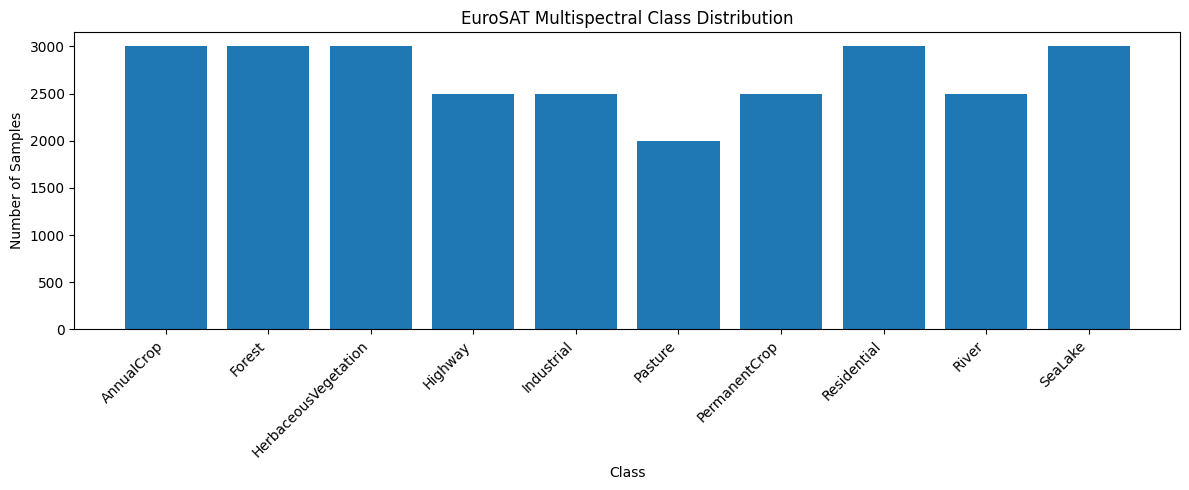

Saved figure to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/class_distribution.png


In [10]:
plt.figure(figsize=(12, 5))
plt.bar(class_distribution["class_name"], class_distribution["num_samples"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("EuroSAT Multispectral Class Distribution")
plt.tight_layout()

class_dist_fig_path = os.path.join(FIGURES_DIR, "class_distribution.png")
plt.savefig(class_dist_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(class_dist_fig_path)

In [11]:
BANDS = {
    "B01": 0,
    "B02": 1,
    "B03": 2,
    "B04": 3,
    "B05": 4,
    "B06": 5,
    "B07": 6,
    "B08": 7,
    "B8A": 8,
    "B09": 9,
    "B10": 10,
    "B11": 11,
    "B12": 12,
}

def normalize_for_display(img, lower_percentile=2, upper_percentile=98):
    """
    Normalize image channels for visualization only.
    This does not change the actual training data.
    """
    img = img.astype(np.float32)
    out = np.zeros_like(img, dtype=np.float32)

    for c in range(img.shape[-1]):
        band = img[:, :, c]
        low = np.percentile(band, lower_percentile)
        high = np.percentile(band, upper_percentile)

        if high > low:
            band = (band - low) / (high - low)
        else:
            band = np.zeros_like(band)

        out[:, :, c] = np.clip(band, 0, 1)

    return out

def get_rgb_image(img):
    """
    True-color RGB visualization using Sentinel-2 bands:
    Red   = B04
    Green = B03
    Blue  = B02
    """
    rgb = img[:, :, [BANDS["B04"], BANDS["B03"], BANDS["B02"]]]
    return normalize_for_display(rgb)

def get_false_color_image(img):
    """
    False-color visualization using Sentinel-2 bands:
    NIR   = B08
    Red   = B04
    Green = B03
    """
    false_color = img[:, :, [BANDS["B08"], BANDS["B04"], BANDS["B03"]]]
    return normalize_for_display(false_color)

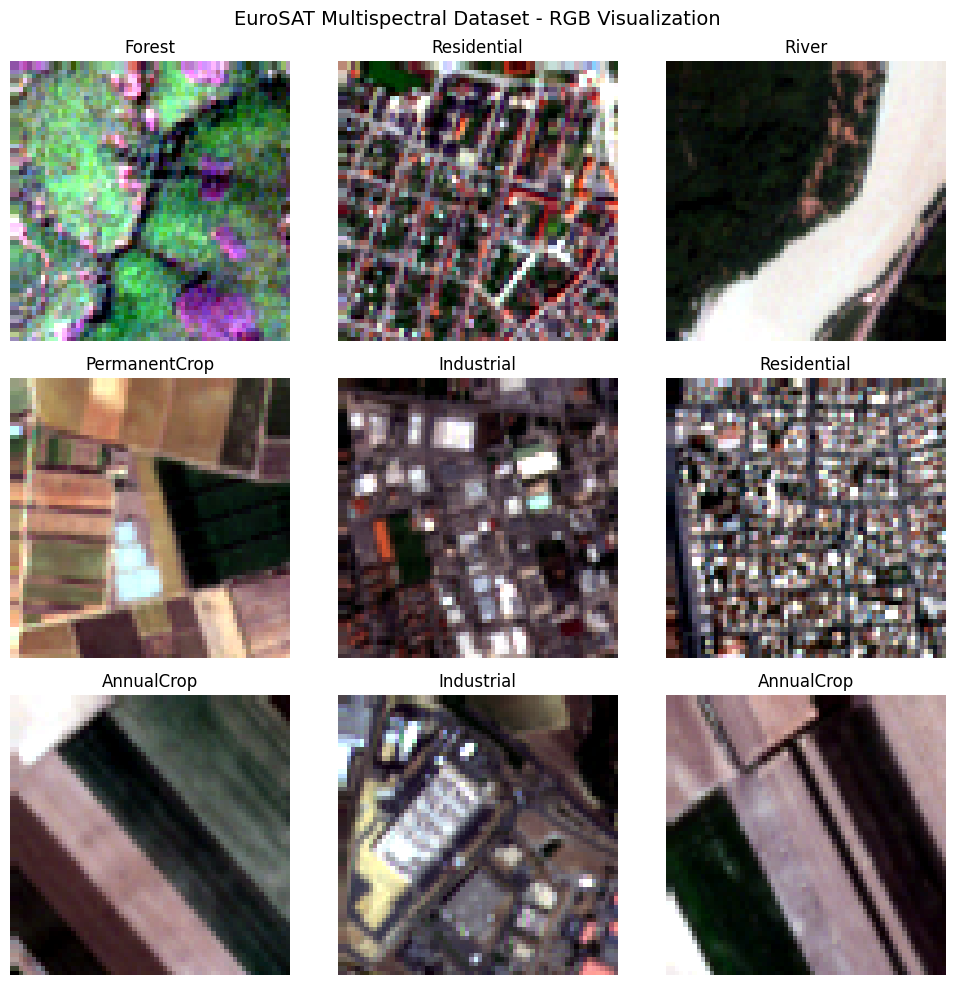

Saved figure to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/rgb_samples.png


In [12]:
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(tif_files), size=9, replace=False)

samples = []

for idx in sample_indices:
    image = read_multispectral_image(tif_files[idx])
    label = labels[idx]
    samples.append((image, label))

plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(samples):
    rgb = get_rgb_image(image)

    plt.subplot(3, 3, i + 1)
    plt.imshow(rgb)
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle("EuroSAT Multispectral Dataset - RGB Visualization", fontsize=14)
plt.tight_layout()

rgb_samples_path = os.path.join(FIGURES_DIR, "rgb_samples.png")
plt.savefig(rgb_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(rgb_samples_path)

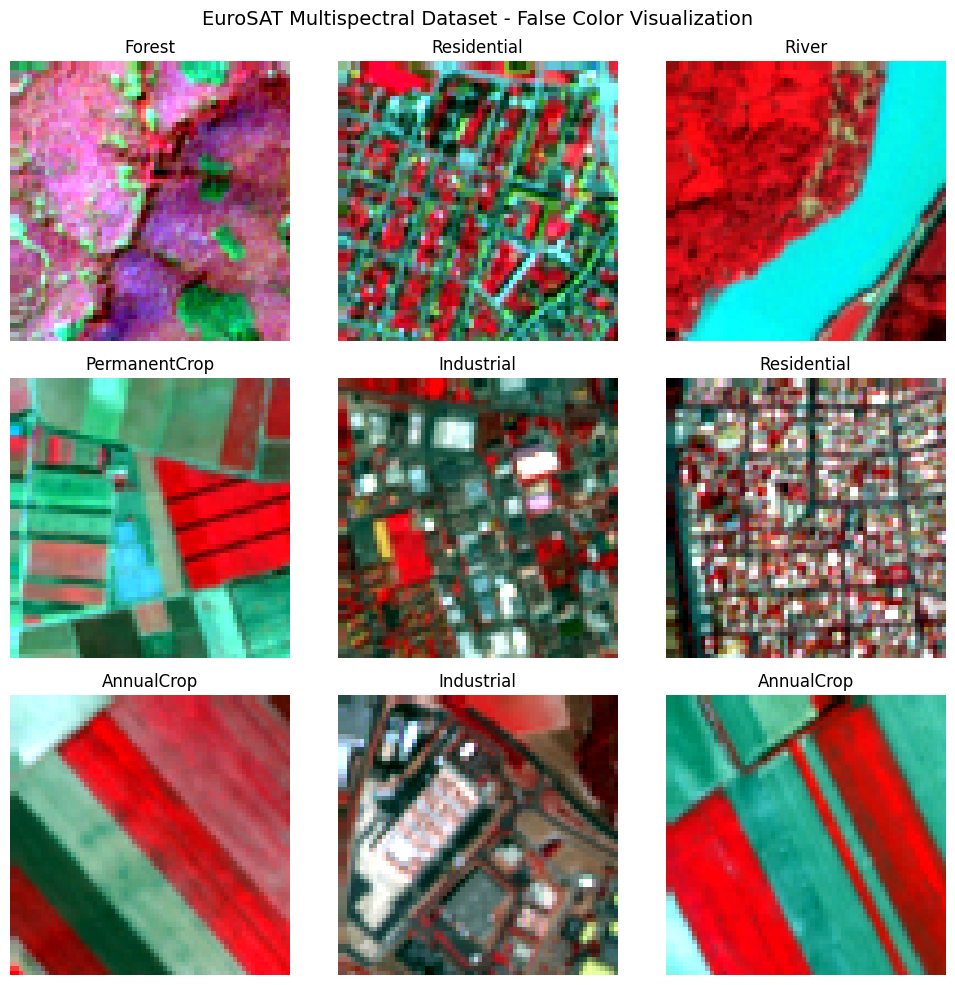

Saved figure to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/false_color_samples.png


In [13]:
plt.figure(figsize=(10, 10))

for i, (image, label) in enumerate(samples):
    false_color = get_false_color_image(image)

    plt.subplot(3, 3, i + 1)
    plt.imshow(false_color)
    plt.title(class_names[label])
    plt.axis("off")

plt.suptitle("EuroSAT Multispectral Dataset - False Color Visualization", fontsize=14)
plt.tight_layout()

false_color_samples_path = os.path.join(FIGURES_DIR, "false_color_samples.png")
plt.savefig(false_color_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(false_color_samples_path)

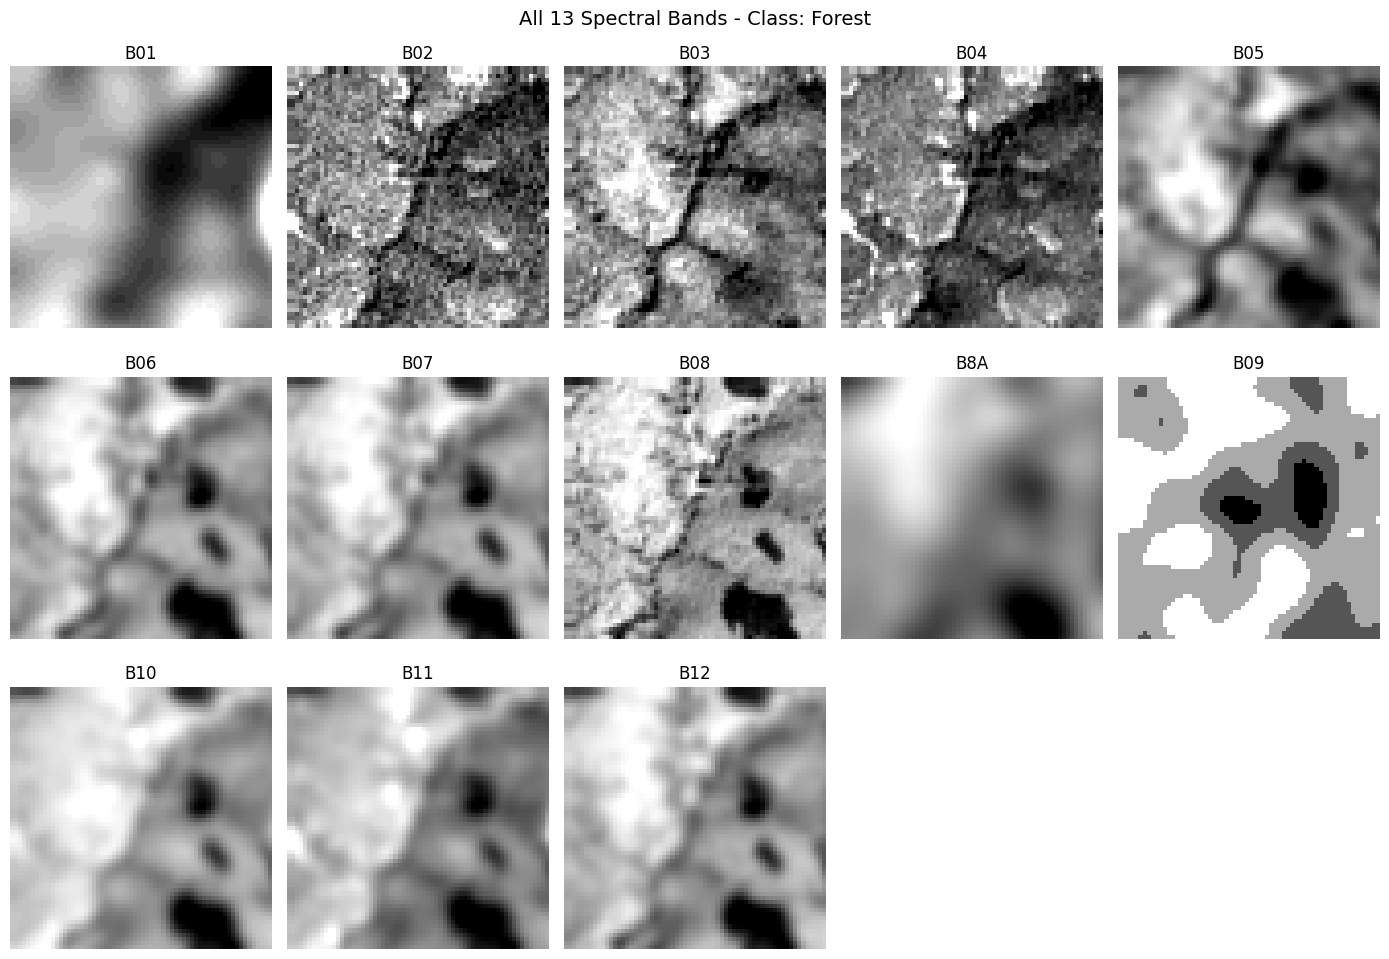

Saved figure to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/all_13_bands_sample.png


In [14]:
image, label = samples[0]

band_names = list(BANDS.keys())

plt.figure(figsize=(14, 10))

for i, band_name in enumerate(band_names):
    band = image[:, :, i]
    band_norm = normalize_for_display(band[:, :, None])[:, :, 0]

    plt.subplot(3, 5, i + 1)
    plt.imshow(band_norm, cmap="gray")
    plt.title(band_name)
    plt.axis("off")

plt.suptitle(f"All 13 Spectral Bands - Class: {class_names[label]}", fontsize=14)
plt.tight_layout()

all_bands_path = os.path.join(FIGURES_DIR, "all_13_bands_sample.png")
plt.savefig(all_bands_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(all_bands_path)

In [15]:
stage1_summary = {
    "dataset_name": DATASET_NAME,
    "num_examples": int(num_examples),
    "num_classes": int(num_classes),
    "image_shape": tuple(sample_image.shape),
    "image_dtype": str(sample_image.dtype),
    "class_names": class_names,
    "saved_outputs": {
        "class_distribution_csv": class_distribution_path,
        "class_distribution_plot": class_dist_fig_path,
        "rgb_samples": rgb_samples_path,
        "false_color_samples": false_color_samples_path,
        "all_13_bands_sample": all_bands_path,
    }
}

stage1_summary

{'dataset_name': 'EuroSAT_MS',
 'num_examples': 27000,
 'num_classes': 10,
 'image_shape': (64, 64, 13),
 'image_dtype': 'float32',
 'class_names': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'saved_outputs': {'class_distribution_csv': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/class_distribution.csv',
  'class_distribution_plot': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/class_distribution.png',
  'rgb_samples': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/rgb_samples.png',
  'false_color_samples': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/false_color_samples.png',
  'all_13_bands_sample': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/all_13_bands_sample.png'}}

In [16]:
from sklearn.model_selection import train_test_split

tif_files_np = np.array(tif_files)
labels_np = np.array(labels)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    tif_files_np,
    labels_np,
    test_size=0.30,
    random_state=SEED,
    stratify=labels_np
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Full split sizes:")
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Full split sizes:
Train: 18900
Validation: 4050
Test: 4050


In [17]:
QUICK_MODE = True

MAX_TRAIN_PER_CLASS = 700
MAX_VAL_PER_CLASS = 150
MAX_TEST_PER_CLASS = 150

def make_balanced_subset(paths, labels, max_per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    paths = np.array(paths)
    labels = np.array(labels)

    selected_indices = []

    for class_id in range(num_classes):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        selected_indices.extend(class_indices[:max_per_class])

    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return paths[selected_indices], labels[selected_indices]

if QUICK_MODE:
    train_paths_used, train_labels_used = make_balanced_subset(
        train_paths, train_labels, MAX_TRAIN_PER_CLASS
    )
    val_paths_used, val_labels_used = make_balanced_subset(
        val_paths, val_labels, MAX_VAL_PER_CLASS
    )
    test_paths_used, test_labels_used = make_balanced_subset(
        test_paths, test_labels, MAX_TEST_PER_CLASS
    )
else:
    train_paths_used, train_labels_used = train_paths, train_labels
    val_paths_used, val_labels_used = val_paths, val_labels
    test_paths_used, test_labels_used = test_paths, test_labels

print("Used split sizes:")
print("Train:", len(train_paths_used))
print("Validation:", len(val_paths_used))
print("Test:", len(test_paths_used))

print("\nQuick mode:", QUICK_MODE)

Used split sizes:
Train: 7000
Validation: 1500
Test: 1500

Quick mode: True


In [18]:
split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "num_samples_full": [len(train_paths), len(val_paths), len(test_paths)],
    "num_samples_used": [len(train_paths_used), len(val_paths_used), len(test_paths_used)]
})

split_summary_path = os.path.join(RESULTS_DIR, "split_summary.csv")
split_summary.to_csv(split_summary_path, index=False)

split_summary

,split,num_samples_full,num_samples_used
0,train,18900,7000
1,validation,4050,1500
2,test,4050,1500


In [19]:
def normalize_image_np(image):
    """
    Normalize raw Sentinel-2 values to approximately [0, 1].
    Sentinel-2 reflectance-like values are commonly scaled by 10000.
    """
    image = image.astype(np.float32) / 10000.0
    image = np.clip(image, 0.0, 1.0)
    return image

def brightness_contrast_shift_np(image, contrast=1.25, brightness=0.06):
    mean = np.mean(image, axis=(0, 1), keepdims=True)
    shifted = (image - mean) * contrast + mean + brightness
    return np.clip(shifted, 0.0, 1.0)

def spectral_noise_np(image, noise_std=0.035, seed=SEED):
    rng = np.random.default_rng(seed)
    noise = rng.normal(0.0, noise_std, size=image.shape).astype(np.float32)
    noisy = image + noise
    return np.clip(noisy, 0.0, 1.0)

def unseen_target_domain_np(image):
    """
    Simulates a stronger unseen domain shift:
    - different spectral response across bands
    - slight brightness shift
    - one weak atmospheric band dropped
    """
    scale = np.array([
        0.85, 0.95, 1.08, 1.12, 0.90, 1.05, 0.95,
        1.15, 0.92, 0.80, 0.00, 1.18, 1.10
    ], dtype=np.float32).reshape(1, 1, 13)

    shifted = image * scale + 0.03
    shifted = np.clip(shifted, 0.0, 1.0)
    return shifted

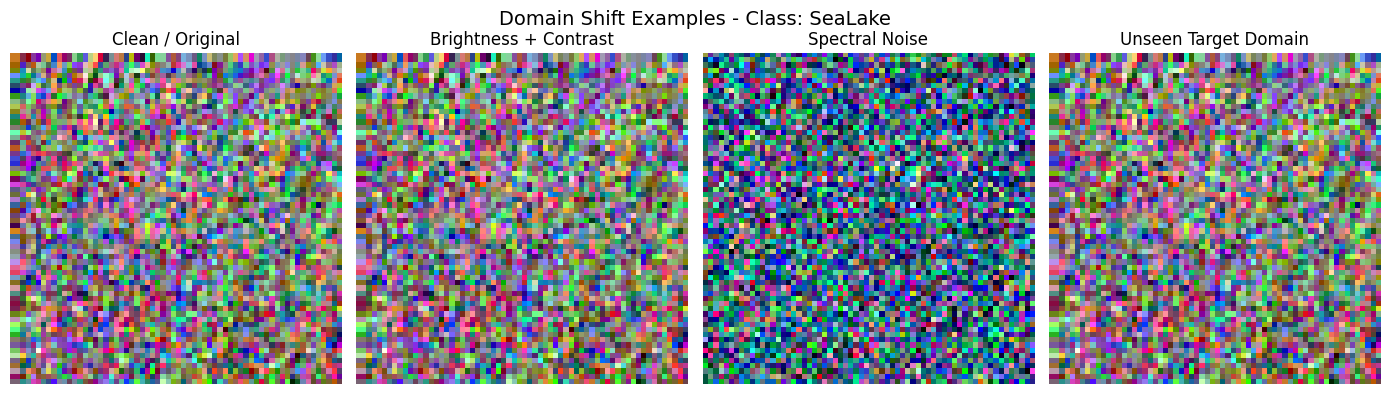

Saved figure to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/domain_shift_examples.png


In [20]:
example_image_raw = read_multispectral_image(train_paths_used[0])
example_label = train_labels_used[0]

example_clean = normalize_image_np(example_image_raw)
example_brightness = brightness_contrast_shift_np(example_clean)
example_noise = spectral_noise_np(example_clean)
example_target = unseen_target_domain_np(example_clean)

domain_examples = [
    ("Clean / Original", example_clean),
    ("Brightness + Contrast", example_brightness),
    ("Spectral Noise", example_noise),
    ("Unseen Target Domain", example_target),
]

plt.figure(figsize=(14, 4))

for i, (title, img) in enumerate(domain_examples):
    plt.subplot(1, 4, i + 1)
    plt.imshow(get_rgb_image(img))
    plt.title(title)
    plt.axis("off")

plt.suptitle(f"Domain Shift Examples - Class: {class_names[example_label]}", fontsize=14)
plt.tight_layout()

domain_shift_examples_path = os.path.join(FIGURES_DIR, "domain_shift_examples.png")
plt.savefig(domain_shift_examples_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(domain_shift_examples_path)

In [21]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64

def load_tif_numpy(path, label):
    path = path.decode("utf-8")

    image = tifffile.imread(path).astype(np.float32)

    if image.shape[0] == 13 and image.shape[-1] != 13:
        image = np.transpose(image, (1, 2, 0))

    label = np.int64(label)
    return image, label

def load_tif_tensorflow(path, label):
    image, label = tf.numpy_function(
        load_tif_numpy,
        [path, label],
        [tf.float32, tf.int64]
    )

    image.set_shape([64, 64, 13])
    label.set_shape([])

    image = image / 10000.0
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, label

def apply_brightness_contrast_tf(image):
    contrast = tf.random.uniform([], 0.75, 1.30)
    brightness = tf.random.uniform([], -0.06, 0.06)

    mean = tf.reduce_mean(image, axis=[0, 1], keepdims=True)
    shifted = (image - mean) * contrast + mean + brightness

    return tf.clip_by_value(shifted, 0.0, 1.0)

def apply_spectral_noise_tf(image):
    noise = tf.random.normal(tf.shape(image), mean=0.0, stddev=0.035)
    noisy = image + noise

    return tf.clip_by_value(noisy, 0.0, 1.0)

def apply_spectral_scale_tf(image):
    scale = tf.random.uniform([1, 1, 13], 0.85, 1.15)
    shifted = image * scale

    return tf.clip_by_value(shifted, 0.0, 1.0)

def apply_domain_randomization_tf(image):
    r = tf.random.uniform([])

    image = tf.cond(
        r < 0.25,
        lambda: image,
        lambda: tf.cond(
            r < 0.50,
            lambda: apply_brightness_contrast_tf(image),
            lambda: tf.cond(
                r < 0.75,
                lambda: apply_spectral_noise_tf(image),
                lambda: apply_spectral_scale_tf(image)
            )
        )
    )

    return image

def apply_unseen_target_domain_tf(image):
    scale = tf.constant([
        0.85, 0.95, 1.08, 1.12, 0.90, 1.05, 0.95,
        1.15, 0.92, 0.80, 0.00, 1.18, 1.10
    ], dtype=tf.float32)

    scale = tf.reshape(scale, [1, 1, 13])
    image = image * scale + 0.03
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image

def select_rgb_bands_tf(image):
    """
    RGB bands:
    Red   = B04 index 3
    Green = B03 index 2
    Blue  = B02 index 1
    """
    return tf.gather(image, [3, 2, 1], axis=-1)

def make_dataset(paths, labels, batch_size=64, shuffle=False, use_rgb=False,
                 domain_randomization=False, unseen_target_domain=False):

    paths = tf.constant(paths.astype(str))
    labels = tf.constant(labels.astype(np.int64))

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(load_tif_tensorflow, num_parallel_calls=AUTOTUNE)

    if unseen_target_domain:
        dataset = dataset.map(
            lambda image, label: (apply_unseen_target_domain_tf(image), label),
            num_parallel_calls=AUTOTUNE
        )

    if domain_randomization:
        dataset = dataset.map(
            lambda image, label: (apply_domain_randomization_tf(image), label),
            num_parallel_calls=AUTOTUNE
        )

    if use_rgb:
        dataset = dataset.map(
            lambda image, label: (select_rgb_bands_tf(image), label),
            num_parallel_calls=AUTOTUNE
        )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset

In [22]:
train_rgb_ds = make_dataset(
    train_paths_used,
    train_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=True,
    use_rgb=True,
    domain_randomization=False
)

val_rgb_ds = make_dataset(
    val_paths_used,
    val_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=True,
    domain_randomization=False
)

train_ms_ds = make_dataset(
    train_paths_used,
    train_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=True,
    use_rgb=False,
    domain_randomization=False
)

val_ms_ds = make_dataset(
    val_paths_used,
    val_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=False,
    domain_randomization=False
)

train_dg_ds = make_dataset(
    train_paths_used,
    train_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=True,
    use_rgb=False,
    domain_randomization=True
)

val_dg_ds = make_dataset(
    val_paths_used,
    val_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=False,
    domain_randomization=False
)

print("Datasets are ready.")
print("RGB input shape: 64 x 64 x 3")
print("Multispectral input shape: 64 x 64 x 13")

Datasets are ready.
RGB input shape: 64 x 64 x 3
Multispectral input shape: 64 x 64 x 13


In [23]:
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
HISTORY_DIR = os.path.join(RESULTS_DIR, "histories")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

def build_cnn_model(input_shape, num_classes, model_name):
    inputs = tf.keras.Input(shape=input_shape)

    x = tf.keras.layers.Conv2D(32, 3, padding="same")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.10)(x)

    x = tf.keras.layers.Conv2D(64, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(64, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.20)(x)

    x = tf.keras.layers.Conv2D(128, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(128, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.40)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

rgb_model = build_cnn_model(
    input_shape=(64, 64, 3),
    num_classes=num_classes,
    model_name="rgb_cnn_baseline"
)

ms_model = build_cnn_model(
    input_shape=(64, 64, 13),
    num_classes=num_classes,
    model_name="multispectral_cnn_baseline"
)

dg_model = build_cnn_model(
    input_shape=(64, 64, 13),
    num_classes=num_classes,
    model_name="multispectral_domain_generalization_cnn"
)

rgb_model.summary()

Model: "rgb_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

In [24]:
EPOCHS = 5

def plot_training_history(history, model_name):
    history_df = pd.DataFrame(history.history)

    history_csv_path = os.path.join(HISTORY_DIR, f"{model_name}_history.csv")
    history_df.to_csv(history_csv_path, index=False)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["accuracy"], label="Train Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()

    plt.tight_layout()

    history_plot_path = os.path.join(FIGURES_DIR, f"{model_name}_training_history.png")
    plt.savefig(history_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    return history_csv_path, history_plot_path

def train_model(model, train_ds, val_ds, model_name):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{model_name}.keras")

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor="val_accuracy",
            save_best_only=True,
            mode="max",
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    print("=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    history_csv_path, history_plot_path = plot_training_history(history, model_name)

    best_val_accuracy = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    summary = {
        "model_name": model_name,
        "checkpoint_path": checkpoint_path,
        "history_csv_path": history_csv_path,
        "history_plot_path": history_plot_path,
        "best_val_accuracy": float(best_val_accuracy),
        "best_val_loss": float(best_val_loss),
        "epochs_trained": len(history.history["loss"])
    }

    return history, summary

Training model: rgb_cnn_baseline
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.4580 - loss: 1.4966
Epoch 1: val_accuracy improved from None to 0.10000, saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/rgb_cnn_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/rgb_cnn_baseline.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 45s 257ms/step - accuracy: 0.5589 - loss: 1.2424 - val_accuracy: 0.1000 - val_loss: 6.0664 - learning_rate: 0.0010
Epoch 2/5
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6909 - loss: 0.8983
Epoch 2: val_accuracy did not improve from 0.10000
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.6930 - loss: 0.8762 - val_accuracy: 0.1000 - val_loss: 6.9134 - learning_rate: 0.0010
Epoch 3/5
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.7136 - loss: 0.8020
Epoch 3: val_accuracy did not improve from 0.10000
110/110 ━━━━━━━━━━━━━━━━━━━

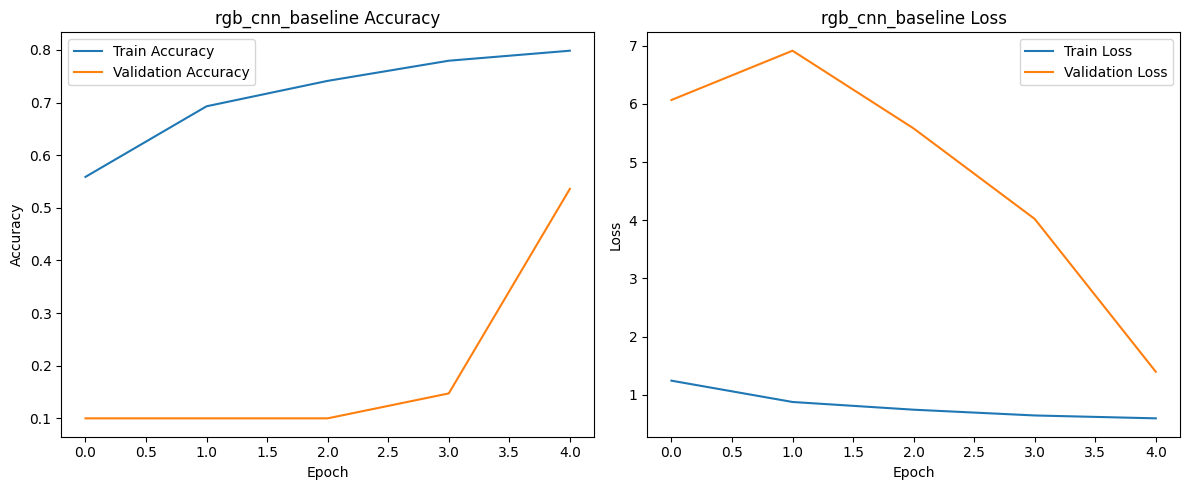

{'model_name': 'rgb_cnn_baseline',
 'checkpoint_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/rgb_cnn_baseline.keras',
 'history_csv_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/histories/rgb_cnn_baseline_history.csv',
 'history_plot_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/rgb_cnn_baseline_training_history.png',
 'best_val_accuracy': 0.5360000133514404,
 'best_val_loss': 1.3958518505096436,
 'epochs_trained': 5}

In [25]:
rgb_history, rgb_summary = train_model(
    model=rgb_model,
    train_ds=train_rgb_ds,
    val_ds=val_rgb_ds,
    model_name="rgb_cnn_baseline"
)

rgb_summary

Training model: multispectral_cnn_baseline
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.6001 - loss: 1.2110
Epoch 1: val_accuracy improved from None to 0.17333, saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_cnn_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_cnn_baseline.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 32s 155ms/step - accuracy: 0.7019 - loss: 0.9139 - val_accuracy: 0.1733 - val_loss: 4.4607 - learning_rate: 0.0010
Epoch 2/5
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8130 - loss: 0.5962
Epoch 2: val_accuracy improved from 0.17333 to 0.19467, saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_cnn_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_cnn_baseline.keras
110/110 ━━━━━

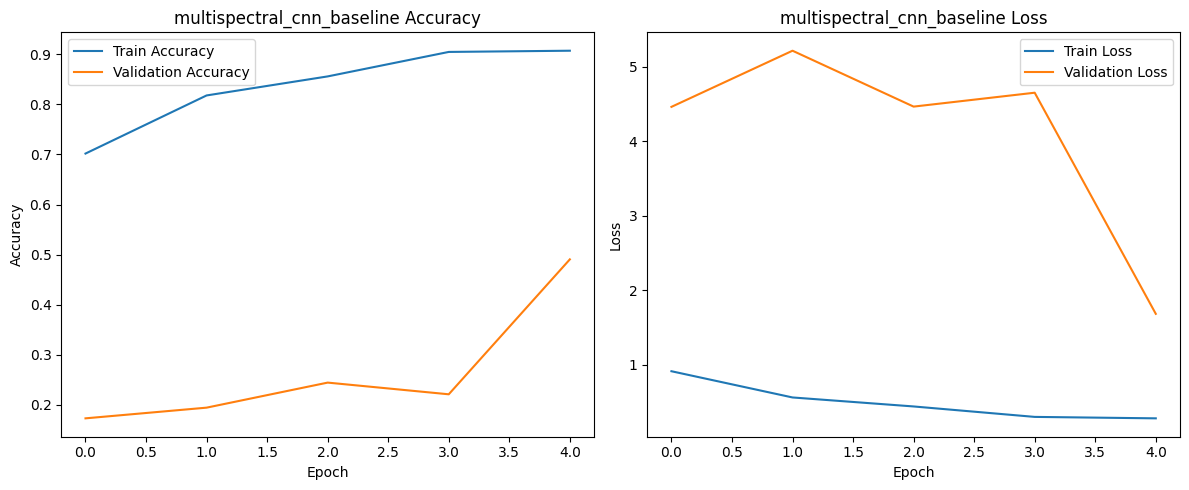

{'model_name': 'multispectral_cnn_baseline',
 'checkpoint_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_cnn_baseline.keras',
 'history_csv_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/histories/multispectral_cnn_baseline_history.csv',
 'history_plot_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/multispectral_cnn_baseline_training_history.png',
 'best_val_accuracy': 0.4906666576862335,
 'best_val_loss': 1.6839309930801392,
 'epochs_trained': 5}

In [26]:
ms_history, ms_summary = train_model(
    model=ms_model,
    train_ds=train_ms_ds,
    val_ds=val_ms_ds,
    model_name="multispectral_cnn_baseline"
)

ms_summary

Training model: multispectral_domain_generalization_cnn
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.5120 - loss: 1.4376
Epoch 1: val_accuracy improved from None to 0.17867, saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_domain_generalization_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_domain_generalization_cnn.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 31s 168ms/step - accuracy: 0.6176 - loss: 1.1537 - val_accuracy: 0.1787 - val_loss: 4.1700 - learning_rate: 0.0010
Epoch 2/5
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7375 - loss: 0.8003
Epoch 2: val_accuracy improved from 0.17867 to 0.25600, saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_domain_generalization_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Multispectral-Domain-Generalization/checkp

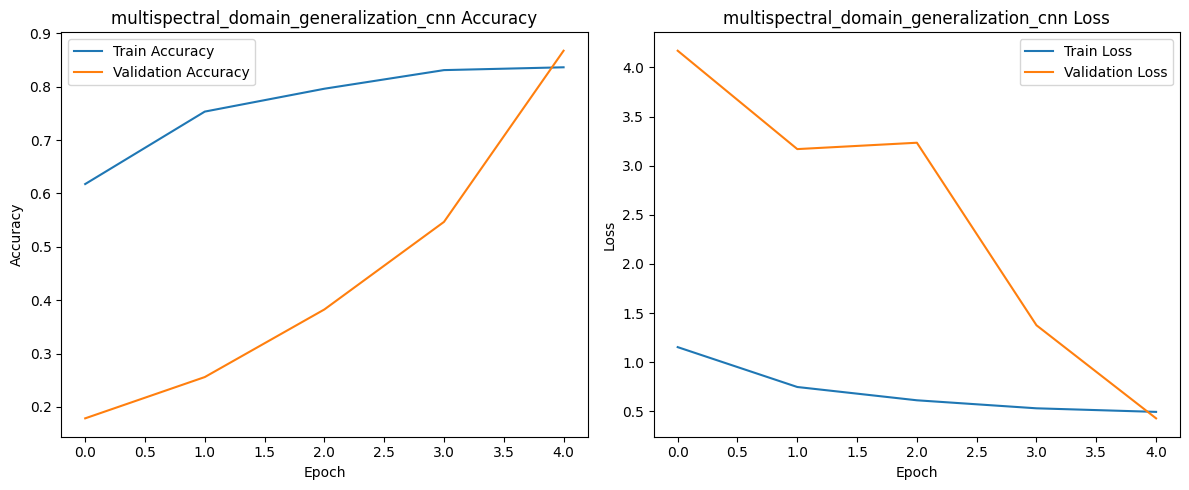

{'model_name': 'multispectral_domain_generalization_cnn',
 'checkpoint_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_domain_generalization_cnn.keras',
 'history_csv_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/histories/multispectral_domain_generalization_cnn_history.csv',
 'history_plot_path': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/multispectral_domain_generalization_cnn_training_history.png',
 'best_val_accuracy': 0.8673333525657654,
 'best_val_loss': 0.4290851354598999,
 'epochs_trained': 5}

In [27]:
dg_history, dg_summary = train_model(
    model=dg_model,
    train_ds=train_dg_ds,
    val_ds=val_dg_ds,
    model_name="multispectral_domain_generalization_cnn"
)

dg_summary

In [28]:
stage3_training_summary = pd.DataFrame([
    rgb_summary,
    ms_summary,
    dg_summary
])

stage3_training_summary_path = os.path.join(RESULTS_DIR, "stage3_training_summary.csv")
stage3_training_summary.to_csv(stage3_training_summary_path, index=False)

stage3_training_summary

,model_name,checkpoint_path,history_csv_path,history_plot_path,best_val_accuracy,best_val_loss,epochs_trained
0,rgb_cnn_baseline,/content/drive/MyDrive/Multispectral-Domain-Ge...,/content/drive/MyDrive/Multispectral-Domain-Ge...,/content/drive/MyDrive/Multispectral-Domain-Ge...,0.536000,1.395852,5
1,multispectral_cnn_baseline,/content/drive/MyDrive/Multispectral-Domain-Ge...,/content/drive/MyDrive/Multispectral-Domain-Ge...,/content/drive/MyDrive/Multispectral-Domain-Ge...,0.490667,1.683931,5
2,multispectral_domain_generalization_cnn,/content/drive/MyDrive/Multispectral-Domain-Ge...,/content/drive/MyDrive/Multispectral-Domain-Ge...,/content/drive/MyDrive/Multispectral-Domain-Ge...,0.867333,0.429085,5


In [29]:
test_rgb_clean_ds = make_dataset(
    test_paths_used,
    test_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=True,
    domain_randomization=False,
    unseen_target_domain=False
)

test_rgb_target_ds = make_dataset(
    test_paths_used,
    test_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=True,
    domain_randomization=False,
    unseen_target_domain=True
)

test_ms_clean_ds = make_dataset(
    test_paths_used,
    test_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=False,
    domain_randomization=False,
    unseen_target_domain=False
)

test_ms_target_ds = make_dataset(
    test_paths_used,
    test_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=False,
    domain_randomization=False,
    unseen_target_domain=True
)

test_dg_clean_ds = make_dataset(
    test_paths_used,
    test_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=False,
    domain_randomization=False,
    unseen_target_domain=False
)

test_dg_target_ds = make_dataset(
    test_paths_used,
    test_labels_used,
    batch_size=BATCH_SIZE,
    shuffle=False,
    use_rgb=False,
    domain_randomization=False,
    unseen_target_domain=True
)

print("Test datasets are ready.")
print("Clean test samples:", len(test_paths_used))
print("Unseen target domain test samples:", len(test_paths_used))

Test datasets are ready.
Clean test samples: 1500
Unseen target domain test samples: 1500


In [30]:
rgb_checkpoint_path = os.path.join(CHECKPOINT_DIR, "rgb_cnn_baseline.keras")
ms_checkpoint_path = os.path.join(CHECKPOINT_DIR, "multispectral_cnn_baseline.keras")
dg_checkpoint_path = os.path.join(CHECKPOINT_DIR, "multispectral_domain_generalization_cnn.keras")

rgb_best_model = tf.keras.models.load_model(rgb_checkpoint_path)
ms_best_model = tf.keras.models.load_model(ms_checkpoint_path)
dg_best_model = tf.keras.models.load_model(dg_checkpoint_path)

print("Loaded best models:")
print(rgb_checkpoint_path)
print(ms_checkpoint_path)
print(dg_checkpoint_path)

Loaded best models:
/content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/rgb_cnn_baseline.keras
/content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_cnn_baseline.keras
/content/drive/MyDrive/Multispectral-Domain-Generalization/checkpoints/multispectral_domain_generalization_cnn.keras


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

EVAL_DIR = os.path.join(RESULTS_DIR, "evaluation")
os.makedirs(EVAL_DIR, exist_ok=True)

def get_predictions(model, dataset):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    return y_true, y_pred, y_prob

def evaluate_model_on_dataset(model, dataset, model_name, domain_name):
    y_true, y_pred, y_prob = get_predictions(model, dataset)

    accuracy = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()

    report_path = os.path.join(
        EVAL_DIR,
        f"{model_name}_{domain_name}_classification_report.csv"
    )
    report_df.to_csv(report_path)

    result = {
        "model_name": model_name,
        "domain": domain_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "classification_report_path": report_path
    }

    return result, y_true, y_pred, y_prob

In [32]:
all_results = {}
all_predictions = {}

evaluation_settings = [
    {
        "model": rgb_best_model,
        "model_name": "rgb_cnn_baseline",
        "clean_dataset": test_rgb_clean_ds,
        "target_dataset": test_rgb_target_ds
    },
    {
        "model": ms_best_model,
        "model_name": "multispectral_cnn_baseline",
        "clean_dataset": test_ms_clean_ds,
        "target_dataset": test_ms_target_ds
    },
    {
        "model": dg_best_model,
        "model_name": "multispectral_domain_generalization_cnn",
        "clean_dataset": test_dg_clean_ds,
        "target_dataset": test_dg_target_ds
    }
]

for setting in evaluation_settings:
    model = setting["model"]
    model_name = setting["model_name"]

    print("=" * 80)
    print("Evaluating:", model_name)
    print("=" * 80)

    clean_result, clean_y_true, clean_y_pred, clean_y_prob = evaluate_model_on_dataset(
        model=model,
        dataset=setting["clean_dataset"],
        model_name=model_name,
        domain_name="clean_test"
    )

    target_result, target_y_true, target_y_pred, target_y_prob = evaluate_model_on_dataset(
        model=model,
        dataset=setting["target_dataset"],
        model_name=model_name,
        domain_name="unseen_target_domain"
    )

    all_results[(model_name, "clean_test")] = clean_result
    all_results[(model_name, "unseen_target_domain")] = target_result

    all_predictions[(model_name, "clean_test")] = {
        "y_true": clean_y_true,
        "y_pred": clean_y_pred,
        "y_prob": clean_y_prob
    }

    all_predictions[(model_name, "unseen_target_domain")] = {
        "y_true": target_y_true,
        "y_pred": target_y_pred,
        "y_prob": target_y_prob
    }

    print("Clean test accuracy:", clean_result["accuracy"])
    print("Unseen target domain accuracy:", target_result["accuracy"])

Evaluating: rgb_cnn_baseline
Clean test accuracy: 0.5386666666666666
Unseen target domain accuracy: 0.45
Evaluating: multispectral_cnn_baseline
Clean test accuracy: 0.49466666666666664
Unseen target domain accuracy: 0.16333333333333333
Evaluating: multispectral_domain_generalization_cnn
Clean test accuracy: 0.8713333333333333
Unseen target domain accuracy: 0.6466666666666666


In [33]:
metrics_summary = pd.DataFrame(list(all_results.values()))

metrics_summary_path = os.path.join(RESULTS_DIR, "stage4_metrics_summary.csv")
metrics_summary.to_csv(metrics_summary_path, index=False)

metrics_summary

,model_name,domain,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,classification_report_path
0,rgb_cnn_baseline,clean_test,0.538667,0.705640,0.538667,0.534936,0.705640,0.538667,0.534936,/content/drive/MyDrive/Multispectral-Domain-Ge...
1,rgb_cnn_baseline,unseen_target_domain,0.450000,0.575914,0.450000,0.427568,0.575914,0.450000,0.427568,/content/drive/MyDrive/Multispectral-Domain-Ge...
2,multispectral_cnn_baseline,clean_test,0.494667,0.729199,0.494667,0.481081,0.729199,0.494667,0.481081,/content/drive/MyDrive/Multispectral-Domain-Ge...
3,multispectral_cnn_baseline,unseen_target_domain,0.163333,0.346359,0.163333,0.113586,0.346359,0.163333,0.113586,/content/drive/MyDrive/Multispectral-Domain-Ge...
4,multispectral_domain_generalization_cnn,clean_test,0.871333,0.880049,0.871333,0.870992,0.880049,0.871333,0.870992,/content/drive/MyDrive/Multispectral-Domain-Ge...
5,multispectral_domain_generalization_cnn,unseen_target_domain,0.646667,0.669901,0.646667,0.609196,0.669901,0.646667,0.609196,/content/drive/MyDrive/Multispectral-Domain-Ge...


In [34]:
comparison_rows = []

for model_name in [
    "rgb_cnn_baseline",
    "multispectral_cnn_baseline",
    "multispectral_domain_generalization_cnn"
]:
    clean = all_results[(model_name, "clean_test")]
    target = all_results[(model_name, "unseen_target_domain")]

    comparison_rows.append({
        "model_name": model_name,
        "clean_accuracy": clean["accuracy"],
        "target_accuracy": target["accuracy"],
        "accuracy_drop": clean["accuracy"] - target["accuracy"],
        "clean_f1_macro": clean["f1_macro"],
        "target_f1_macro": target["f1_macro"],
        "f1_drop": clean["f1_macro"] - target["f1_macro"]
    })

comparison_table = pd.DataFrame(comparison_rows)

comparison_table_path = os.path.join(RESULTS_DIR, "model_comparison_table.csv")
comparison_table.to_csv(comparison_table_path, index=False)

comparison_table

,model_name,clean_accuracy,target_accuracy,accuracy_drop,clean_f1_macro,target_f1_macro,f1_drop
0,rgb_cnn_baseline,0.538667,0.450000,0.088667,0.534936,0.427568,0.107367
1,multispectral_cnn_baseline,0.494667,0.163333,0.331333,0.481081,0.113586,0.367495
2,multispectral_domain_generalization_cnn,0.871333,0.646667,0.224667,0.870992,0.609196,0.261796


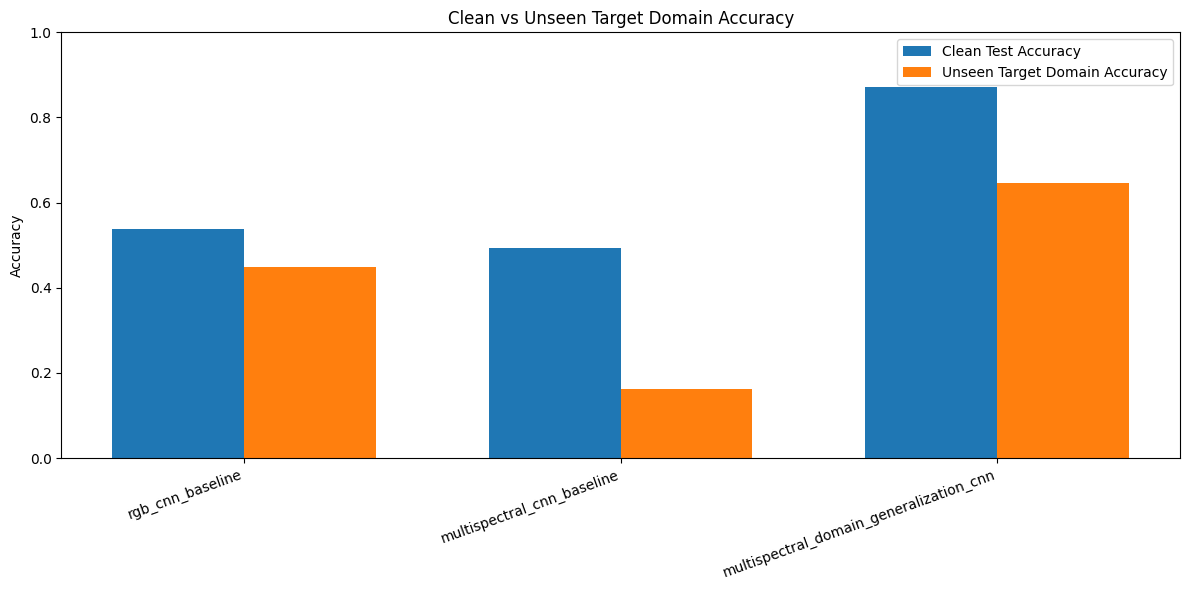

Saved figure to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/model_comparison_accuracy.png


In [35]:
x = np.arange(len(comparison_table))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    comparison_table["clean_accuracy"],
    width,
    label="Clean Test Accuracy"
)

plt.bar(
    x + width / 2,
    comparison_table["target_accuracy"],
    width,
    label="Unseen Target Domain Accuracy"
)

plt.xticks(x, comparison_table["model_name"], rotation=20, ha="right")
plt.ylabel("Accuracy")
plt.title("Clean vs Unseen Target Domain Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

model_comparison_plot_path = os.path.join(FIGURES_DIR, "model_comparison_accuracy.png")
plt.savefig(model_comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:")
print(model_comparison_plot_path)

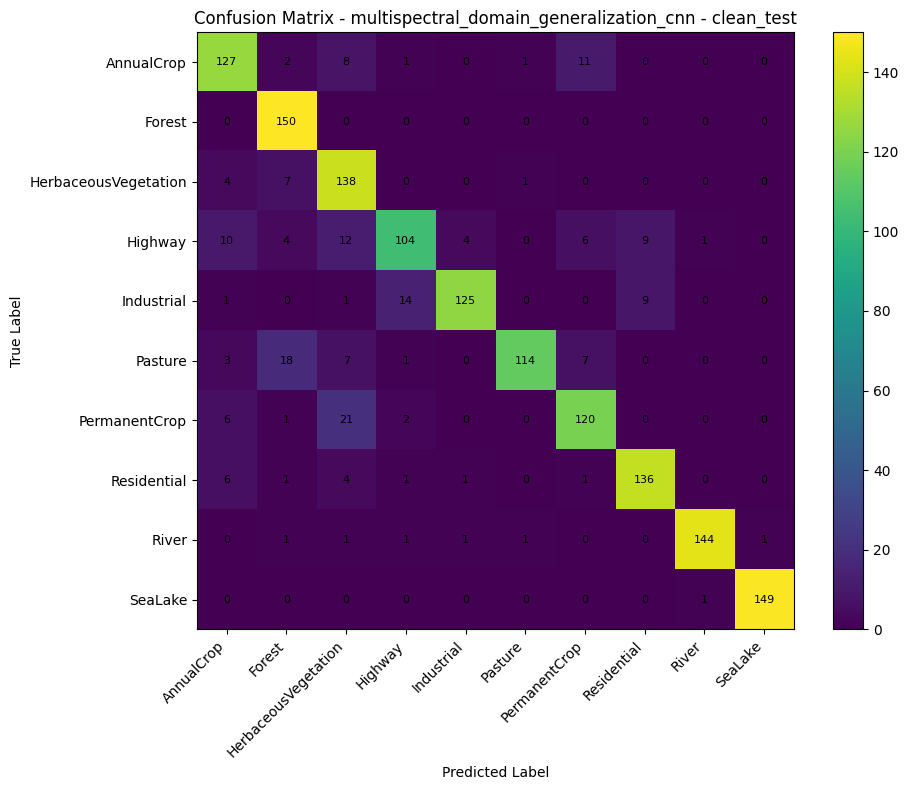

Saved confusion matrix to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/confusion_matrix_multispectral_domain_generalization_cnn_clean_test.png


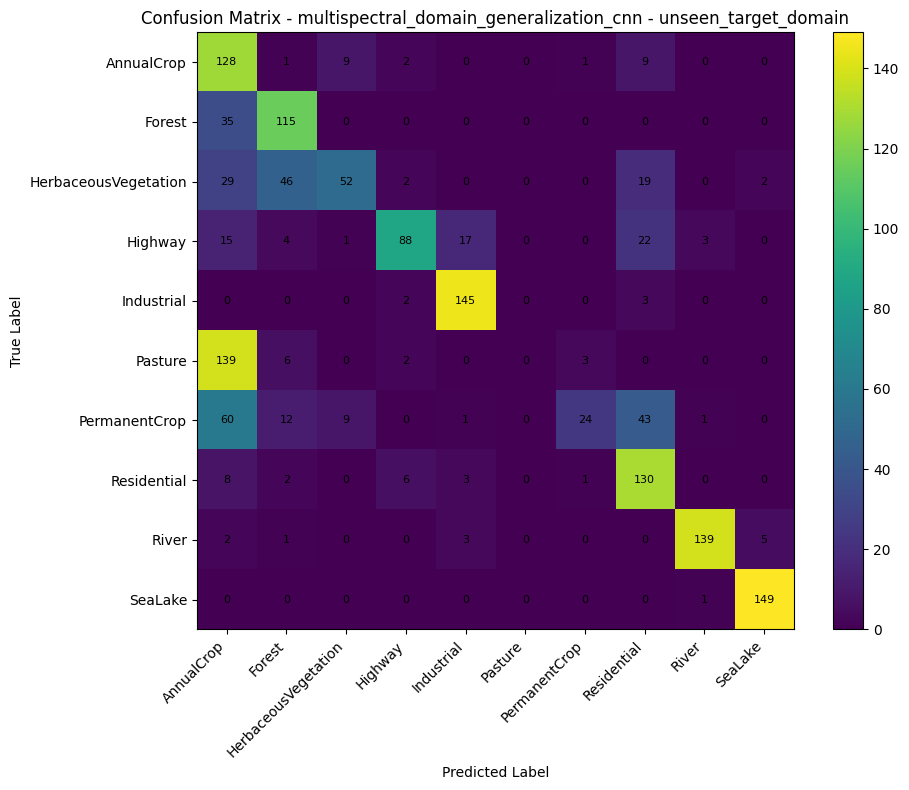

Saved confusion matrix to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/confusion_matrix_multispectral_domain_generalization_cnn_unseen_target_domain.png


In [36]:
best_model_name = "multispectral_domain_generalization_cnn"

for domain_name in ["clean_test", "unseen_target_domain"]:
    y_true = all_predictions[(best_model_name, domain_name)]["y_true"]
    y_pred = all_predictions[(best_model_name, domain_name)]["y_pred"]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {best_model_name} - {domain_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(np.arange(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(np.arange(num_classes), class_names)

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)

    plt.colorbar()
    plt.tight_layout()

    cm_path = os.path.join(FIGURES_DIR, f"confusion_matrix_{best_model_name}_{domain_name}.png")
    plt.savefig(cm_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved confusion matrix to:")
    print(cm_path)

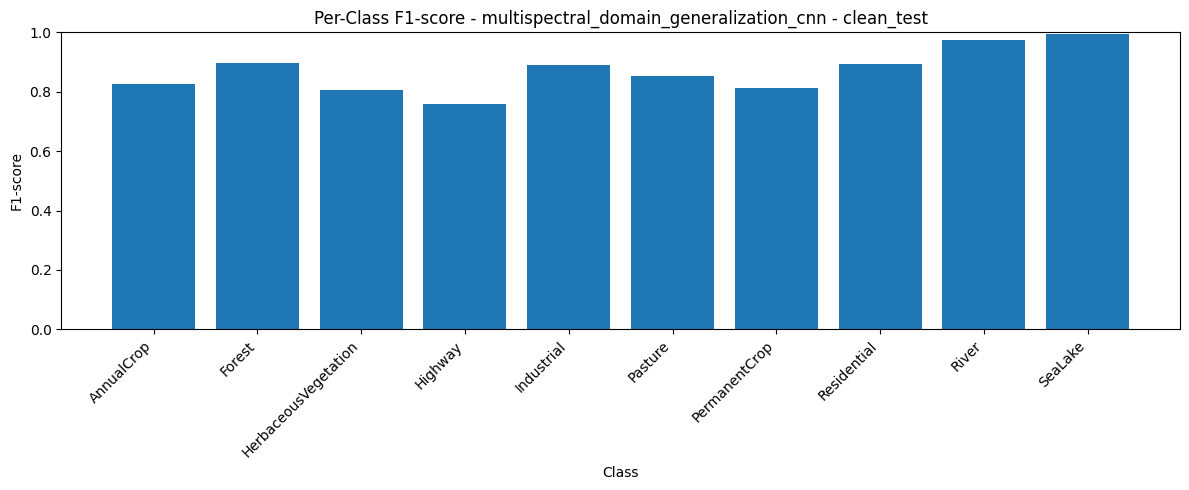

Saved per-class F1 plot to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/per_class_f1_multispectral_domain_generalization_cnn_clean_test.png


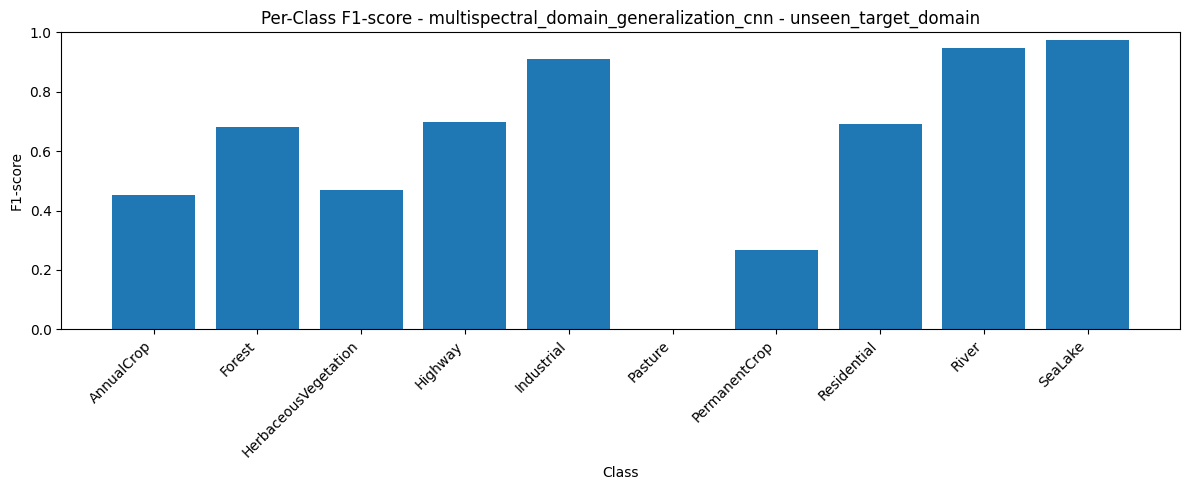

Saved per-class F1 plot to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/per_class_f1_multispectral_domain_generalization_cnn_unseen_target_domain.png


In [37]:
for domain_name in ["clean_test", "unseen_target_domain"]:
    report_path = all_results[(best_model_name, domain_name)]["classification_report_path"]
    report_df = pd.read_csv(report_path, index_col=0)

    per_class_df = report_df.loc[class_names].copy()
    per_class_f1 = per_class_df["f1-score"].values

    plt.figure(figsize=(12, 5))
    plt.bar(class_names, per_class_f1)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)
    plt.xlabel("Class")
    plt.ylabel("F1-score")
    plt.title(f"Per-Class F1-score - {best_model_name} - {domain_name}")
    plt.tight_layout()

    f1_plot_path = os.path.join(FIGURES_DIR, f"per_class_f1_{best_model_name}_{domain_name}.png")
    plt.savefig(f1_plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved per-class F1 plot to:")
    print(f1_plot_path)

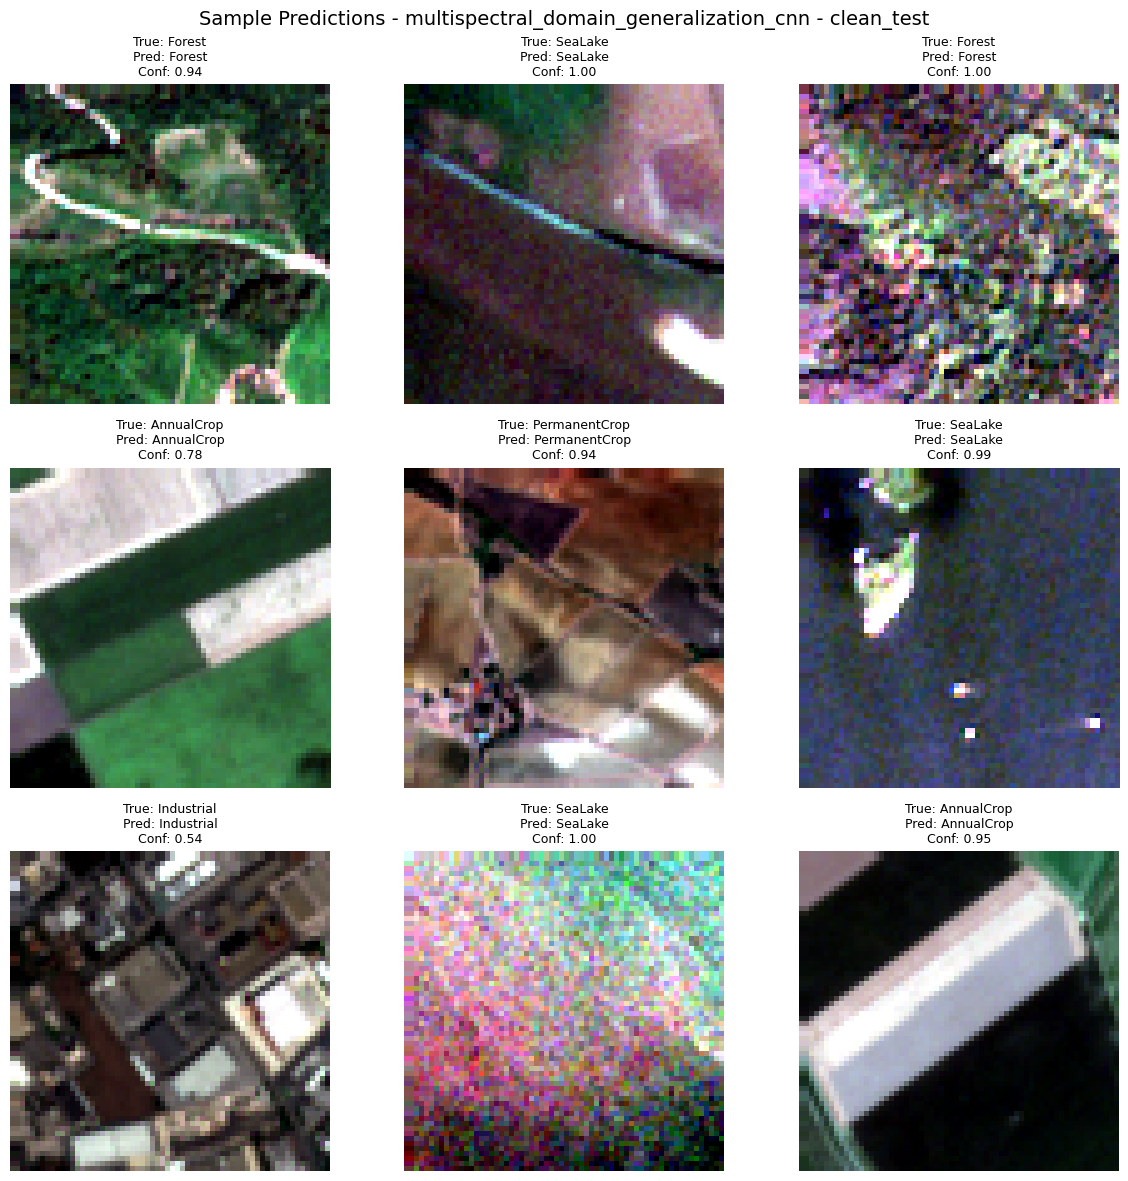

Saved sample predictions to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/sample_predictions_multispectral_domain_generalization_cnn_clean_test.png


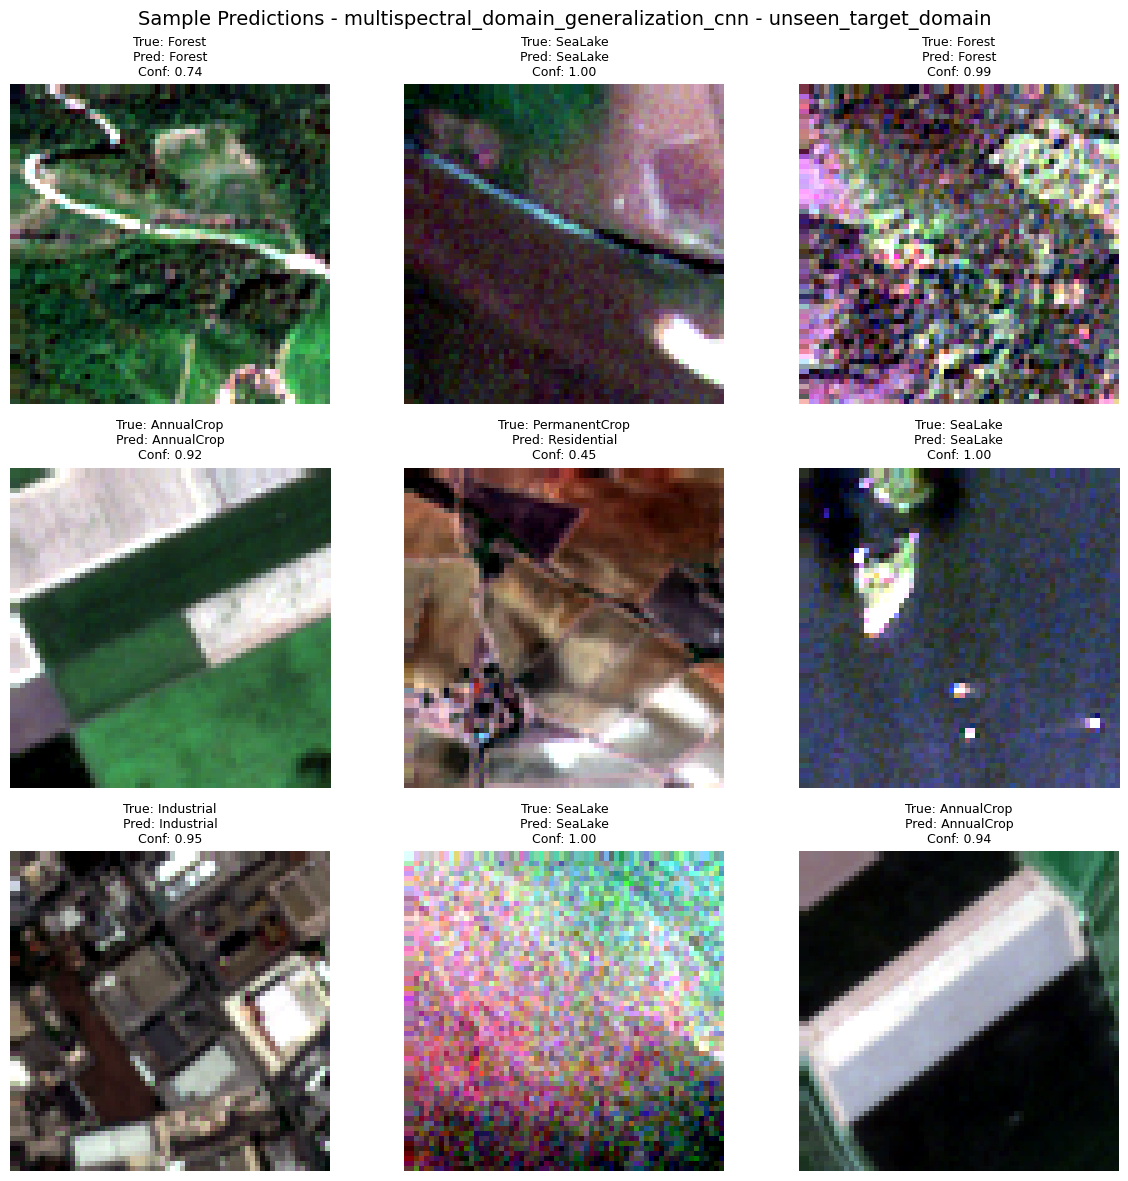

Saved sample predictions to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/sample_predictions_multispectral_domain_generalization_cnn_unseen_target_domain.png


In [38]:
def prepare_image_for_model(path, use_rgb=False, unseen_target=False):
    image_raw = read_multispectral_image(path)
    image = normalize_image_np(image_raw)

    if unseen_target:
        image = unseen_target_domain_np(image)

    if use_rgb:
        image = image[:, :, [BANDS["B04"], BANDS["B03"], BANDS["B02"]]]

    return image.astype(np.float32)

def visualize_predictions(model, model_name, unseen_target=False, num_samples=9):
    rng = np.random.default_rng(SEED + 10)

    sample_indices = rng.choice(len(test_paths_used), size=num_samples, replace=False)

    plt.figure(figsize=(12, 12))

    for i, idx in enumerate(sample_indices):
        path = test_paths_used[idx]
        true_label = test_labels_used[idx]

        image = prepare_image_for_model(
            path,
            use_rgb=False,
            unseen_target=unseen_target
        )

        probs = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
        pred_label = int(np.argmax(probs))
        confidence = float(np.max(probs))

        display_img = get_rgb_image(image)

        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Conf: {confidence:.2f}"
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(display_img)
        plt.title(title, fontsize=9)
        plt.axis("off")

    domain_text = "unseen_target_domain" if unseen_target else "clean_test"
    plt.suptitle(f"Sample Predictions - {model_name} - {domain_text}", fontsize=14)
    plt.tight_layout()

    pred_fig_path = os.path.join(
        FIGURES_DIR,
        f"sample_predictions_{model_name}_{domain_text}.png"
    )

    plt.savefig(pred_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved sample predictions to:")
    print(pred_fig_path)

visualize_predictions(
    model=dg_best_model,
    model_name=best_model_name,
    unseen_target=False,
    num_samples=9
)

visualize_predictions(
    model=dg_best_model,
    model_name=best_model_name,
    unseen_target=True,
    num_samples=9
)

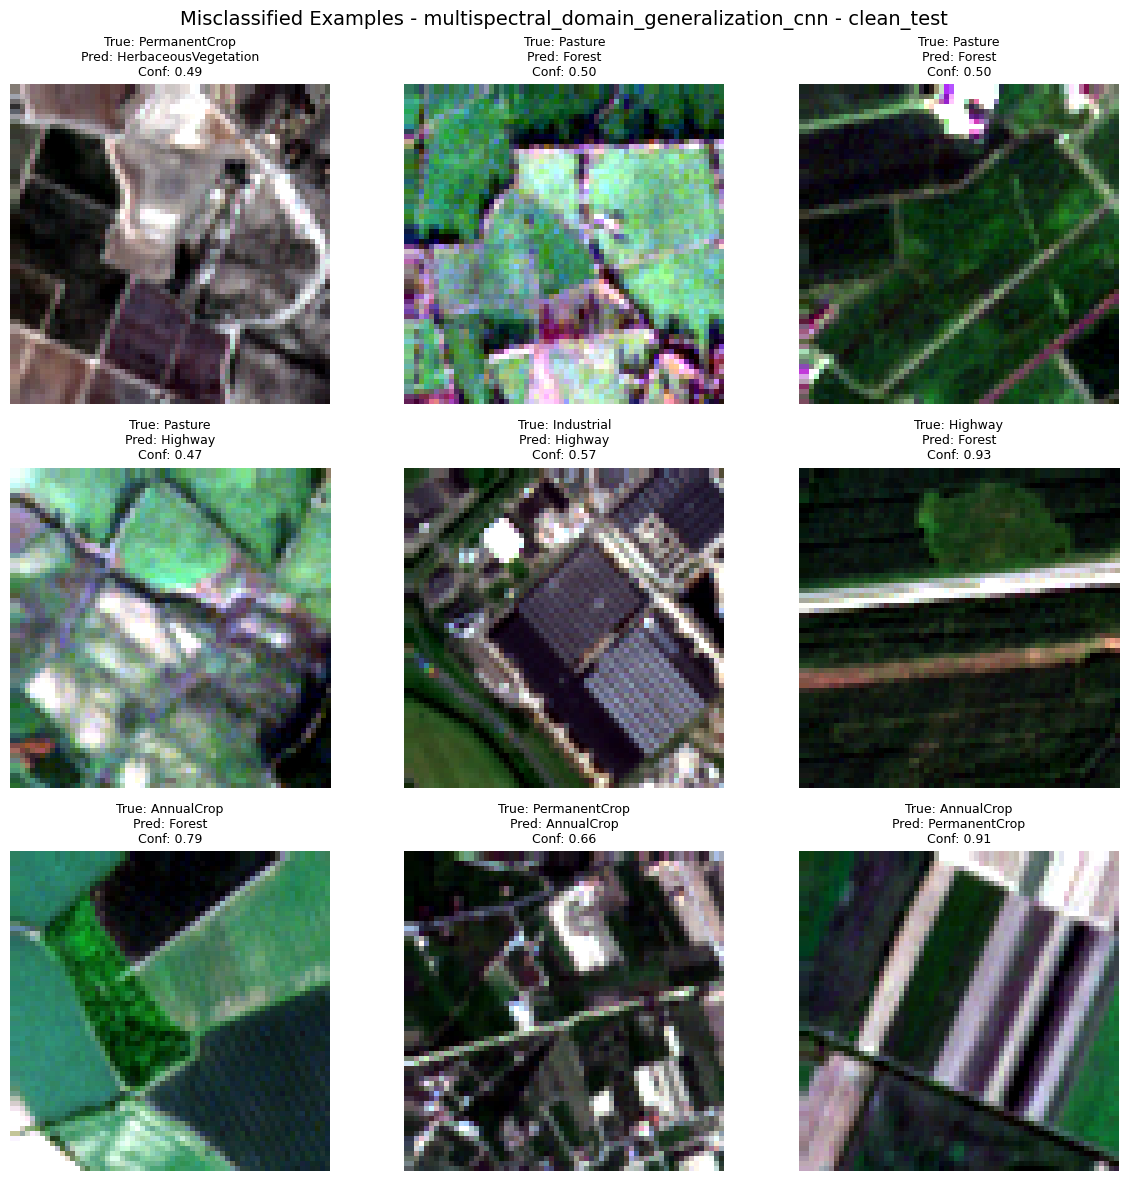

Number of misclassified examples: 193
Saved misclassified examples to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/misclassified_examples_multispectral_domain_generalization_cnn_clean_test.png


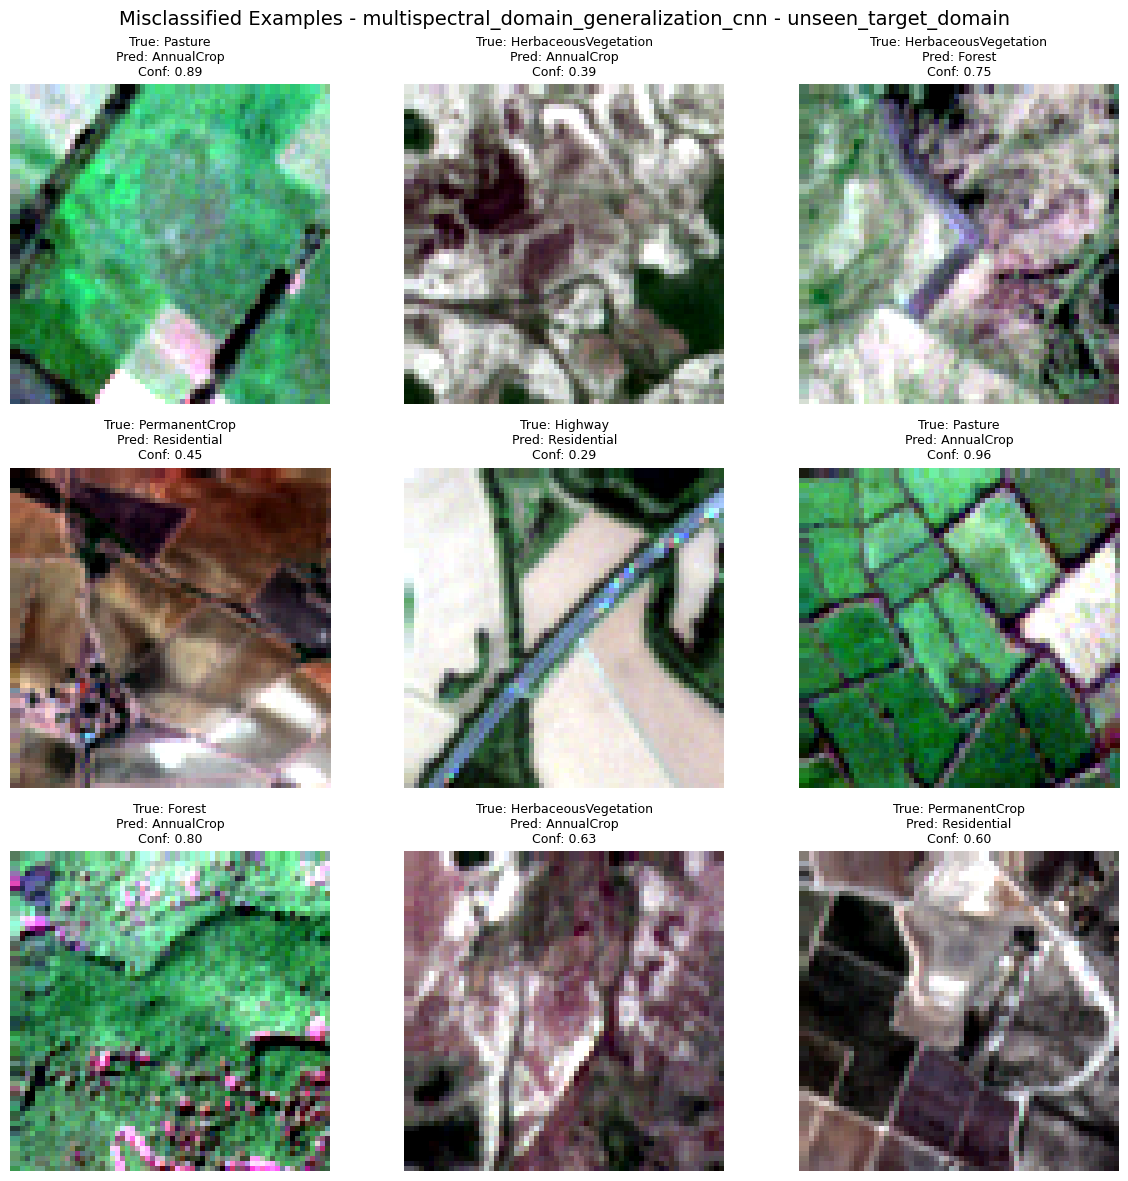

Number of misclassified examples: 530
Saved misclassified examples to:
/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/misclassified_examples_multispectral_domain_generalization_cnn_unseen_target_domain.png


In [39]:
def visualize_misclassified_examples(model, model_name, unseen_target=False, max_samples=9):
    domain_name = "unseen_target_domain" if unseen_target else "clean_test"

    y_true = all_predictions[(model_name, domain_name)]["y_true"]
    y_pred = all_predictions[(model_name, domain_name)]["y_pred"]
    y_prob = all_predictions[(model_name, domain_name)]["y_prob"]

    wrong_indices = np.where(y_true != y_pred)[0]

    if len(wrong_indices) == 0:
        print("No misclassified examples found.")
        return

    selected = wrong_indices[:max_samples]

    plt.figure(figsize=(12, 12))

    for i, idx in enumerate(selected):
        path = test_paths_used[idx]
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        confidence = float(np.max(y_prob[idx]))

        image = prepare_image_for_model(
            path,
            use_rgb=False,
            unseen_target=unseen_target
        )

        display_img = get_rgb_image(image)

        title = (
            f"True: {class_names[true_label]}\n"
            f"Pred: {class_names[pred_label]}\n"
            f"Conf: {confidence:.2f}"
        )

        plt.subplot(3, 3, i + 1)
        plt.imshow(display_img)
        plt.title(title, fontsize=9)
        plt.axis("off")

    plt.suptitle(f"Misclassified Examples - {model_name} - {domain_name}", fontsize=14)
    plt.tight_layout()

    misclassified_path = os.path.join(
        FIGURES_DIR,
        f"misclassified_examples_{model_name}_{domain_name}.png"
    )

    plt.savefig(misclassified_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Number of misclassified examples:", len(wrong_indices))
    print("Saved misclassified examples to:")
    print(misclassified_path)

visualize_misclassified_examples(
    model=dg_best_model,
    model_name=best_model_name,
    unseen_target=False,
    max_samples=9
)

visualize_misclassified_examples(
    model=dg_best_model,
    model_name=best_model_name,
    unseen_target=True,
    max_samples=9
)

In [40]:
final_project_summary = {
    "project_title": "Multispectral Domain Generalization for Land-Cover Classification Using EuroSAT",
    "dataset": "EuroSAT_MS",
    "num_classes": int(num_classes),
    "image_shape": tuple(sample_image.shape),
    "quick_mode": QUICK_MODE,
    "train_samples_used": int(len(train_paths_used)),
    "val_samples_used": int(len(val_paths_used)),
    "test_samples_used": int(len(test_paths_used)),
    "models": [
        "RGB CNN Baseline",
        "Multispectral CNN Baseline",
        "Multispectral Domain Generalization CNN"
    ],
    "main_outputs": {
        "stage3_training_summary": stage3_training_summary_path,
        "stage4_metrics_summary": metrics_summary_path,
        "model_comparison_table": comparison_table_path,
        "model_comparison_plot": model_comparison_plot_path
    }
}

final_summary_path = os.path.join(RESULTS_DIR, "final_project_summary.txt")

with open(final_summary_path, "w") as f:
    for key, value in final_project_summary.items():
        f.write(f"{key}: {value}\n")

final_project_summary

{'project_title': 'Multispectral Domain Generalization for Land-Cover Classification Using EuroSAT',
 'dataset': 'EuroSAT_MS',
 'num_classes': 10,
 'image_shape': (64, 64, 13),
 'quick_mode': True,
 'train_samples_used': 7000,
 'val_samples_used': 1500,
 'test_samples_used': 1500,
 'models': ['RGB CNN Baseline',
  'Multispectral CNN Baseline',
  'Multispectral Domain Generalization CNN'],
 'main_outputs': {'stage3_training_summary': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/stage3_training_summary.csv',
  'stage4_metrics_summary': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/stage4_metrics_summary.csv',
  'model_comparison_table': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/model_comparison_table.csv',
  'model_comparison_plot': '/content/drive/MyDrive/Multispectral-Domain-Generalization/results/figures/model_comparison_accuracy.png'}}